# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Sulaiman Faiz Tsaqib | 5054251048|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import CategoricalNB, BernoulliNB, MultinomialNB

In [2]:
# Load dataset dan tampilkan beberapa baris pertama.
# Semua nilai pada dataset berupa single character yang merupakan kode singkatan dari kategori.
# Contoh: pada kolom class, e = edible dan p = poisonous.
df = pd.read_csv('mushrooms.csv')
df.head()


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [3]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
# Perhatikan kolom stalk-root yang memiliki nilai '?' sebagai representasi missing value.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

In [4]:
# Tampilkan jumlah nilai unik pada setiap fitur.
# Perhatikan variasi jumlah kategori antar fitur, misalnya veil-type hanya punya 1 nilai unik.
nunique = df.nunique().sort_values(ascending=False)
print(nunique)

gill-color                  12
cap-color                   10
odor                         9
stalk-color-below-ring       9
spore-print-color            9
stalk-color-above-ring       9
habitat                      7
cap-shape                    6
population                   6
stalk-root                   5
ring-type                    5
stalk-surface-above-ring     4
veil-color                   4
stalk-surface-below-ring     4
cap-surface                  4
ring-number                  3
gill-attachment              2
class                        2
bruises                      2
gill-size                    2
gill-spacing                 2
stalk-shape                  2
veil-type                    1
dtype: int64


class
e    4208
p    3916
Name: count, dtype: int64
class
e    51.797144
p    48.202856
Name: count, dtype: float64


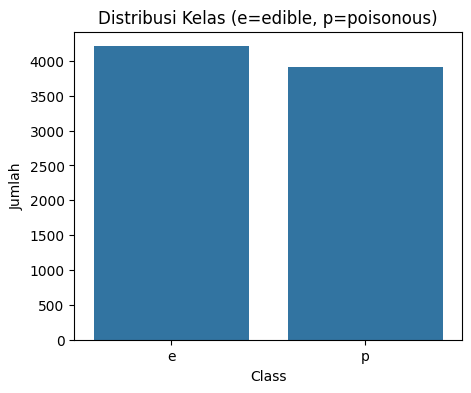

In [5]:
# Tampilkan distribusi kelas target (class) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
class_counts = df['class'].value_counts()
print(class_counts)
print(class_counts / len(df) * 100)

plt.figure(figsize=(5, 4))
sns.countplot(x='class', data=df, order=class_counts.index)
plt.title('Distribusi Kelas (e=edible, p=poisonous)')
plt.xlabel('Class')
plt.ylabel('Jumlah')
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

Jumlah baris duplikat:

 0



Jumlah nilai '?' per kolom:
stalk-root    2480
dtype: int64


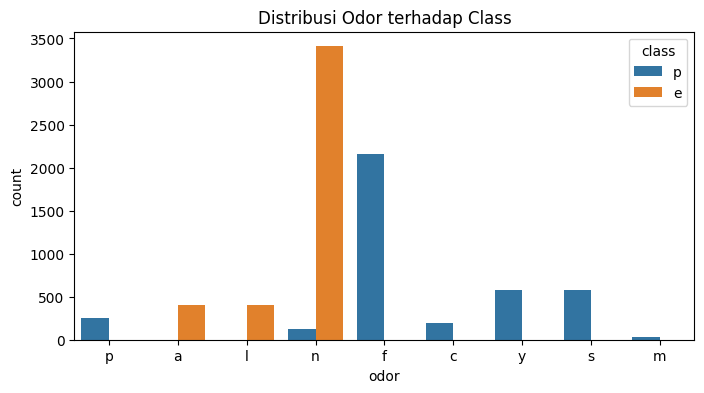

In [6]:
# Cek duplikat baris
print("Jumlah baris duplikat:", df.duplicated().sum())

# Cek nilai '?' (missing value tersembunyi) per kolom
missing_mark = (df == '?').sum()
print("\nJumlah nilai '?' per kolom:")
print(missing_mark[missing_mark > 0])

# Contoh hubungan salah satu fitur (odor) dengan class
plt.figure(figsize=(8, 4))
sns.countplot(x='odor', hue='class', data=df)
plt.title('Distribusi Odor terhadap Class')
plt.show()

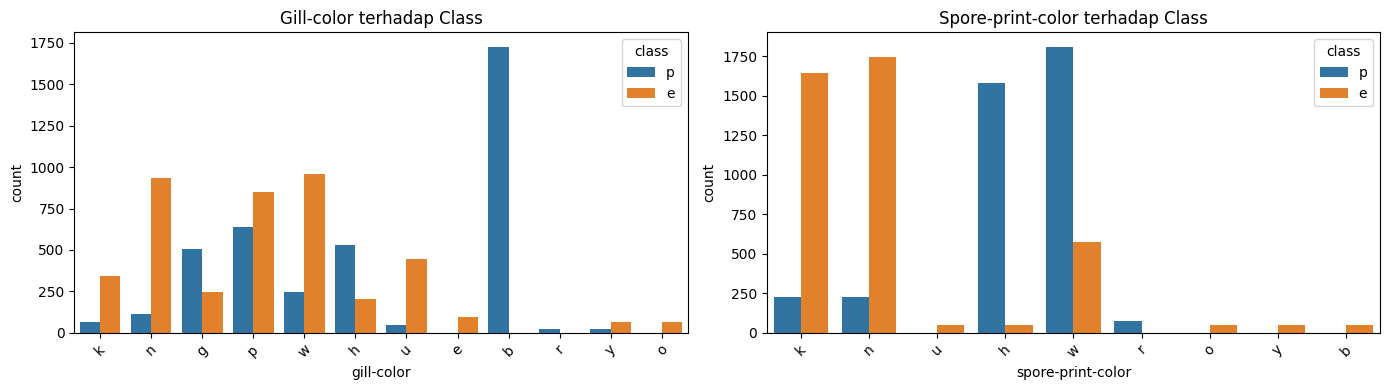

In [7]:
# Analisis bivariat: hubungan beberapa fitur kategorikal lain dengan class
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(x='gill-color', hue='class', data=df, ax=axes[0])
axes[0].set_title('Gill-color terhadap Class')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(x='spore-print-color', hue='class', data=df, ax=axes[1])
axes[1].set_title('Spore-print-color terhadap Class')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

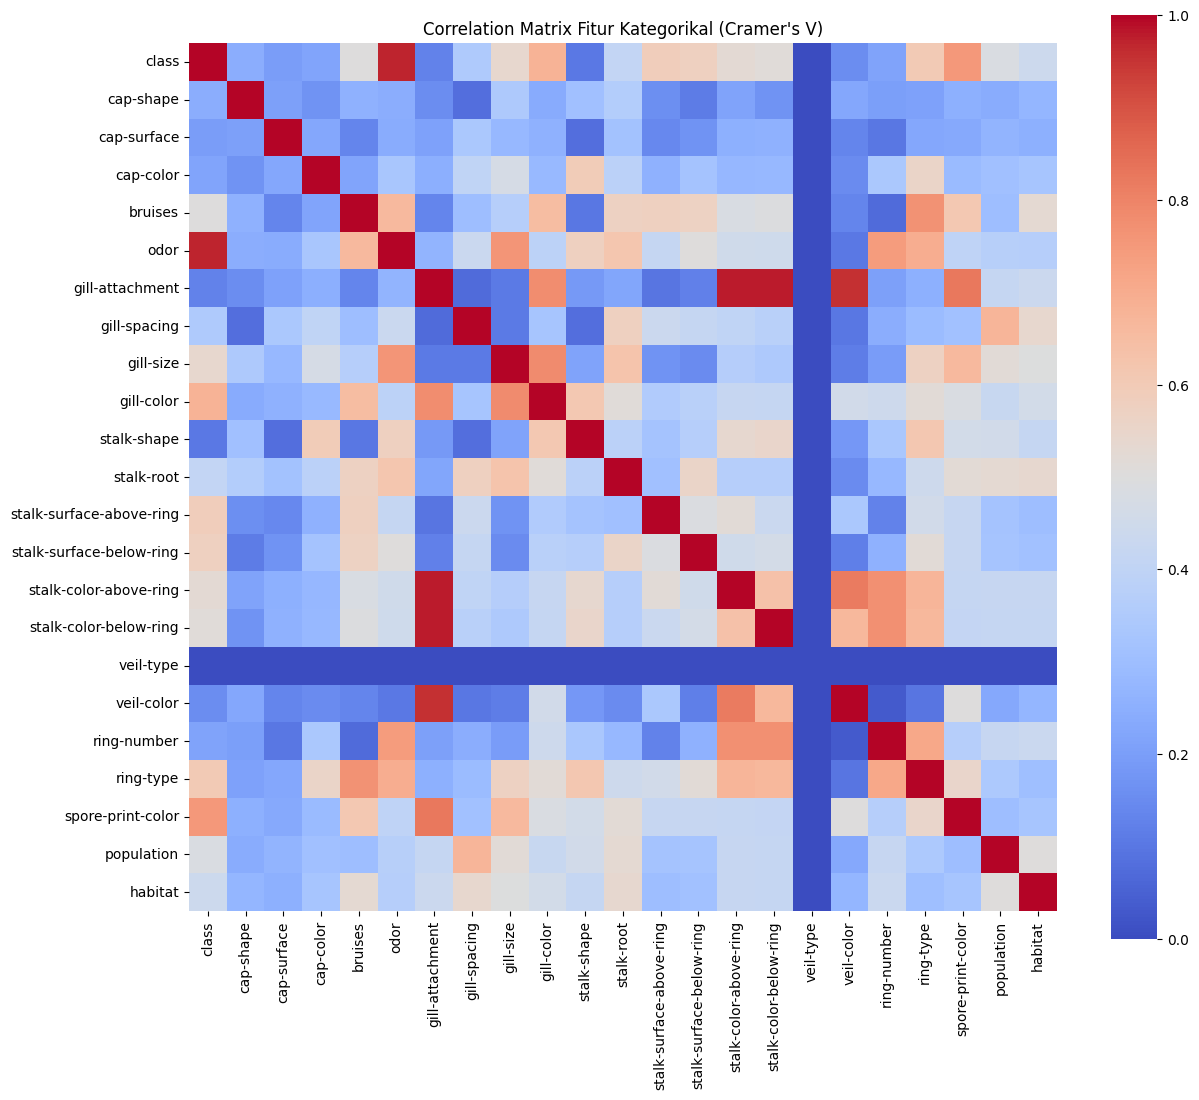

class                       0.999753
odor                        0.971005
spore-print-color           0.752645
gill-color                  0.680830
ring-type                   0.603271
stalk-surface-above-ring    0.587944
stalk-surface-below-ring    0.574837
gill-size                   0.539758
stalk-color-above-ring      0.524850
stalk-color-below-ring      0.514725
bruises                     0.501280
population                  0.487376
habitat                     0.440136
stalk-root                  0.406805
gill-spacing                0.348052
cap-shape                   0.245571
cap-color                   0.218427
ring-number                 0.214772
cap-surface                 0.196925
veil-color                  0.153421
gill-attachment             0.128424
stalk-shape                 0.101770
veil-type                   0.000000
Name: class, dtype: float64


In [8]:
# Correlation matrix untuk fitur kategorikal menggunakan Cramer's V
from scipy.stats import chi2_contingency

def cramers_v(col1, col2):
    confusion = pd.crosstab(col1, col2)
    r, k = confusion.shape
    if min(r, k) <= 1:
        return 0.0
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    return np.sqrt((chi2 / n) / (min(r, k) - 1))

cols = df.columns
cramers_matrix = pd.DataFrame(np.zeros((len(cols), len(cols))), index=cols, columns=cols)
for c1 in cols:
    for c2 in cols:
        cramers_matrix.loc[c1, c2] = cramers_v(df[c1], df[c2])

plt.figure(figsize=(14, 12))
sns.heatmap(cramers_matrix, cmap='coolwarm', annot=False, square=True)
plt.title("Correlation Matrix Fitur Kategorikal (Cramer's V)")
plt.show()

# Fitur dengan korelasi tertinggi terhadap class
print(cramers_matrix['class'].sort_values(ascending=False))

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [9]:
# Tangani missing value pada kolom stalk-root (nilai '?').
# Strategi: jadikan '?' sebagai kategori tersendiri (bukan drop baris/modus),
# karena jumlahnya besar (2480 dari 8124 baris, ~30%) sehingga drop akan membuang banyak data,
# dan secara biologis "akar tidak teridentifikasi" bisa jadi informasi tersendiri (bukan acak).
print("Kategori unik stalk-root sebelum:", df['stalk-root'].unique())
df['stalk-root'] = df['stalk-root'].replace('?', 'missing')
print("Kategori unik stalk-root sesudah:", df['stalk-root'].unique())

Kategori unik stalk-root sebelum: <StringArray>
['e', 'c', 'b', 'r', '?']
Length: 5, dtype: str
Kategori unik stalk-root sesudah: <StringArray>
['e', 'c', 'b', 'r', 'missing']
Length: 5, dtype: str


In [10]:
# Periksa apakah ada fitur yang hanya memiliki satu nilai unik.
# Fitur seperti itu tidak memberikan informasi apapun dan sebaiknya di-drop.
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
print("Fitur konstan (di-drop):", constant_cols)

df = df.drop(columns=constant_cols)
print("Jumlah kolom setelah drop:", df.shape[1])

Fitur konstan (di-drop): ['veil-type']
Jumlah kolom setelah drop: 22


In [11]:
# Pisahkan fitur (X) dan target (y).
# Encode target: e = 0 (edible), p = 1 (poisonous).
X = df.drop(columns=['class'])
y = df['class'].map({'e': 0, 'p': 1})

# Bagi data menjadi train set dan test set (80:20), stratify=y agar distribusi kelas tetap proporsional.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Distribusi y_train:\n", y_train.value_counts(normalize=True))
print("Distribusi y_test:\n", y_test.value_counts(normalize=True))

X_train: (6499, 21) | X_test: (1625, 21)
Distribusi y_train:
 class
0    0.517926
1    0.482074
Name: proportion, dtype: float64
Distribusi y_test:
 class
0    0.518154
1    0.481846
Name: proportion, dtype: float64


In [12]:
# Preprocessing untuk Categorical NB:
# Gunakan OrdinalEncoder untuk mengubah setiap kategori menjadi integer.
# Fit hanya pada train set, transform pada train set dan test set.
ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_ord = ordinal_encoder.fit_transform(X_train)
X_test_ord = ordinal_encoder.transform(X_test)

print("Shape X_train_ord:", X_train_ord.shape)
print("Contoh kategori cap-shape:", ordinal_encoder.categories_[list(X.columns).index('cap-shape')])

Shape X_train_ord: (6499, 21)
Contoh kategori cap-shape: ['b' 'c' 'f' 'k' 's' 'x']


In [13]:
# Preprocessing untuk Bernoulli NB dan Multinomial NB:
# Gunakan OneHotEncoder untuk mengubah setiap kategori menjadi representasi binary.
# Fit hanya pada train set, transform pada train set dan test set.
from sklearn.preprocessing import OneHotEncoder

onehot_encoder = OneHotEncoder(handle_unknown='ignore')
X_train_ohe = onehot_encoder.fit_transform(X_train)
X_test_ohe = onehot_encoder.transform(X_test)

print("Shape X_train_ohe:", X_train_ohe.shape)
print("Tipe data:", type(X_train_ohe))

Shape X_train_ohe: (6499, 116)
Tipe data: <class 'scipy.sparse._csr.csr_matrix'>


# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [14]:
# Inisialisasi dan latih model CategoricalNB menggunakan train set hasil OrdinalEncoder.
cat_nb = CategoricalNB()
cat_nb.fit(X_train_ord, y_train)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None
Name,Type,Value
"category_count_ category_count_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the number of samplesencountered for each class and category of the specific feature.",list,"[array([[ 324.... 0., 1382.]]), array([[1248....134., 1368.]]), array([[ 38.... 542.]]), array([[1161....634., 499.]]), ...]"
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3366.,3133.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.66,-0.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_log_prob_ feature_log_prob_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the empirical log probabilityof categories given the respective feature and class, ``P(x_i|y)``.",list,"[array([[-2.33...-0.81964923]]), array([[-0.99...-0.82918638]]), array([[-4.46...-1.75582372]]), array([[-1.06...-1.83577635]]), ...]"


In [15]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_cat = cat_nb.predict(X_test_ord)
y_proba_cat = cat_nb.predict_proba(X_test_ord)[:, 1]

print("Contoh prediksi:", y_pred_cat[:10])
print("Contoh probabilitas kelas 1:", y_proba_cat[:10])

Contoh prediksi: [1 0 0 1 1 0 0 0 0 0]
Contoh probabilitas kelas 1: [1.00000000e+00 3.69231318e-01 1.69422230e-06 1.00000000e+00
 1.00000000e+00 2.32133395e-07 2.39370910e-08 4.33080758e-07
 7.46792155e-06 2.02738864e-01]


## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [16]:
# Inisialisasi dan latih model BernoulliNB menggunakan train set hasil OneHotEncoder.
bern_nb = BernoulliNB()
bern_nb.fit(X_train_ohe, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3366.,3133.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Log probability of each class (smoothed).","ndarray[float64](2,)","[-0.66,-0.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 116)","[[ 324., 0.,1276.,..., 109., 80., 157.], [ 37., 4.,1241.,..., 782., 221., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of features given a class, P(x_i|y).","ndarray[float64](2, 116)","[[-2.34,-8.12,-0.97,...,-3.42,-3.73,-3.06], [-4.41,-6.44,-0.93,...,-1.39,-2.65,-8.05]]"


In [17]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_bern = bern_nb.predict(X_test_ohe)
y_proba_bern = bern_nb.predict_proba(X_test_ohe)[:, 1]

print("Contoh prediksi:", y_pred_bern[:10])
print("Contoh probabilitas kelas 1:", y_proba_bern[:10])

Contoh prediksi: [1 0 0 1 1 0 0 0 0 0]
Contoh probabilitas kelas 1: [1.00000000e+00 4.06871535e-01 2.58243564e-09 1.00000000e+00
 1.00000000e+00 4.14263609e-09 7.49221190e-10 9.27108223e-09
 2.09551000e-08 6.80420491e-02]


## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [18]:
# Inisialisasi dan latih model MultinomialNB menggunakan train set hasil OneHotEncoder.
multi_nb = MultinomialNB()
multi_nb.fit(X_train_ohe, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3366.,3133.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.66,-0.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 116)","[[ 324., 0.,1276.,..., 109., 80., 157.], [ 37., 4.,1241.,..., 782., 221., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 116)","[[ -5.38,-11.17, -4.02,..., -6.47, -6.77, -6.11], [ -7.46, -9.49, -3.97,..., -4.43, -5.69,-11.1 ]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,116


In [19]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_multi = multi_nb.predict(X_test_ohe)
y_proba_multi = multi_nb.predict_proba(X_test_ohe)[:, 1]

print("Contoh prediksi:", y_pred_multi[:10])
print("Contoh probabilitas kelas 1:", y_proba_multi[:10])

Contoh prediksi: [1 0 0 1 1 0 0 0 0 0]
Contoh probabilitas kelas 1: [1.00000000e+00 3.69231017e-01 1.69422011e-06 1.00000000e+00
 1.00000000e+00 2.32133095e-07 2.39370600e-08 4.33080197e-07
 7.46791188e-06 2.02738655e-01]


# 4. Evaluasi Model

In [20]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, roc_auc_score

results = {
    'Categorical NB': (y_pred_cat, y_proba_cat),
    'Bernoulli NB': (y_pred_bern, y_proba_bern),
    'Multinomial NB': (y_pred_multi, y_proba_multi),
}

metrics_table = pd.DataFrame({
    name: {
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
    }
    for name, (pred, proba) in results.items()
}).T

metrics_table

,Accuracy,Precision,Recall,F1-Score
Categorical NB,0.945846,0.990127,0.896552,0.941019
Bernoulli NB,0.932923,0.981429,0.877395,0.926500
Multinomial NB,0.945846,0.990127,0.896552,0.941019


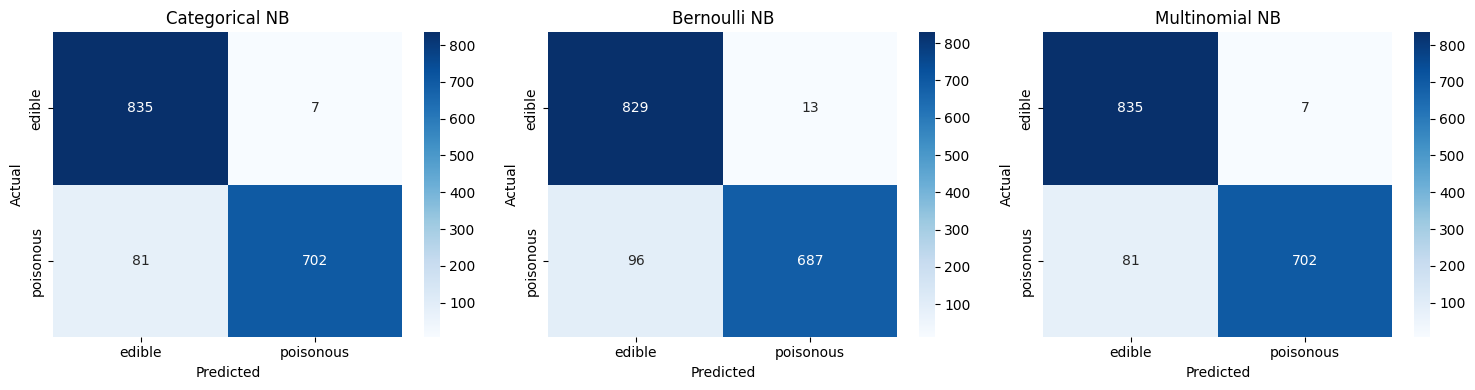

In [21]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
# Susun ketiganya dalam satu baris subplot.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, (pred, proba)) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['edible', 'poisonous'], yticklabels=['edible', 'poisonous'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

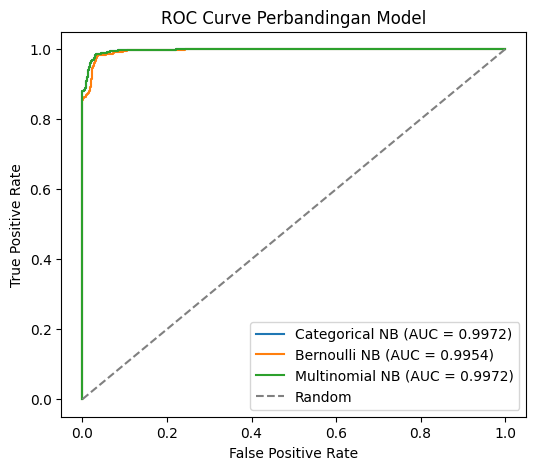

In [22]:
# Tampilkan ROC Curve ketiga model dalam satu plot beserta nilai AUC masing-masing.
plt.figure(figsize=(6, 5))

for name, (pred, proba) in results.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Perbandingan Model')
plt.legend()
plt.show()

# 5. Analisis

| Model | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|
| Categorical NB | 0.9458 | 0.9901 | 0.8966 | 0.9410 |
| Bernoulli NB | 0.9329 | 0.9814 | 0.8774 | 0.9265 |
| Multinomial NB | 0.9458 | 0.9901 | 0.8966 | 0.9410 |

- **Categorical NB = Multinomial NB (identik)**: setelah one-hot encoding, tiap sampel punya jumlah kategori aktif yang sama (21 fitur, masing-masing tepat 1 kolom bernilai 1). Total hitungan konstan ini membuat likelihood MultinomialNB matematis setara dengan P(kategori|kelas) pada CategoricalNB.
- **Bernoulli NB lebih rendah** (accuracy -1.3pp, recall -1.9pp): BernoulliNB memodelkan probabilitas ketidakhadiran kategori (nilai 0), padahal pada one-hot nilai 0 cuma konsekuensi otomatis dari nilai 1 di kolom lain pada kelompok fitur sama, bukan informasi independen, sehingga estimasinya bias.
- **Precision tinggi (~0.98-0.99) vs recall lebih rendah (~0.88-0.90)** di ketiga model: ~10-12% jamur poisonous diprediksi edible (false negative) — risiko lebih berbahaya dibanding false positive untuk kasus keamanan pangan.
- **Kaitan dengan Cramér's V**: `odor` berkorelasi 0.971 terhadap class (hampir deterministik), disusul `spore-print-color` (0.753) dan `gill-color` (0.681). Sinyal sekuat ini menjelaskan performa tetap tinggi meski asumsi independensi antar fitur kemungkinan dilanggar.

# 6. Kesimpulan dan Saran

**Kesimpulan**
- Categorical NB dan Multinomial NB terbaik dan setara (accuracy 94.58%, F1 94.10%); Bernoulli NB sedikit tertinggal karena representasi biner one-hot kurang sesuai untuk fitur kategorikal multi-kelas.
- Categorical NB paling tepat secara konseptual: tidak butuh one-hot encoding (cukup ordinal), performa identik dengan Multinomial NB, lebih efisien (21 vs 116 kolom fitur).
- Recall kelas poisonous belum sempurna (~89-90%) — model masih berisiko meloloskan jamur beracun sebagai "aman", kelemahan kritis untuk konteks ini.

**Saran**
- Bandingkan strategi imputasi `stalk-root` lain (modus, drop baris) untuk uji sensitivitas preprocessing.
- Uji feature selection pakai fitur Cramér's V tertinggi saja (odor, spore-print-color, gill-color, ring-type).
- Tuning decision threshold / class_prior untuk naikkan recall poisonous, meski precision sedikit turun — trade-off lebih dapat diterima daripada risiko false negative.
- Validasi dengan k-fold cross-validation, bukan single train-test split.
- Tambah model pembanding non-NB (Decision Tree / Logistic Regression) untuk lihat dampak pelanggaran asumsi independensi.